# BIRSVD tutorial

This notebook demonstrates BIRSVD on synthetic 2D image-like data. BIRSVD is an algorithm for weighted low-rank matrix approximation that alternately updates the left and right low-rank factors while applying regularization. It shows how weighted low-rank reconstruction can recover missing structure and how repeated low-rank fitting can separate a smooth background from sparse positive signals.

1. Low-rank reconstruction: fit a low-rank model to partially observed weighted data and inspect the reconstruction residual.
2. Sparse + low-rank decomposition: alternate between low-rank reconstruction and sparse residual updates to separate background and signal components.

Reference: Das, S. and Neumaier, A. (2011). *Fast Regularized Low Rank Approximation of Weighted Data Sets*. https://api.semanticscholar.org/CorpusID:9775806


In [1]:
from matplotlib import rcParams
import matplotlib.pyplot as plt

import numpy as np
from birsvd import birsvd

rcParams['legend.frameon'] = False
rcParams['image.origin'] = 'lower'

## Low-rank reconstruction

The next cell constructs a reproducible low-rank matrix with additive Gaussian noise. It also creates a binary weight matrix that marks which entries are treated as observed during the BIRSVD fit.


In [2]:
rng = np.random.default_rng(42)

m, n, r = 100, 80, 5
U = rng.standard_normal((m, r))
V = rng.standard_normal((n, r))
S = rng.exponential(size=r)
data   = (U @ np.diag(S) @ V.T) + 0.1 * rng.standard_normal((m, n))
weight = (rng.random((m, n)) > 0.5).astype('float')

The next cell visualizes the complete synthetic data, the binary weight mask, and the partially observed matrix. This helps confirm which regions of the data are available to the weighted approximation.


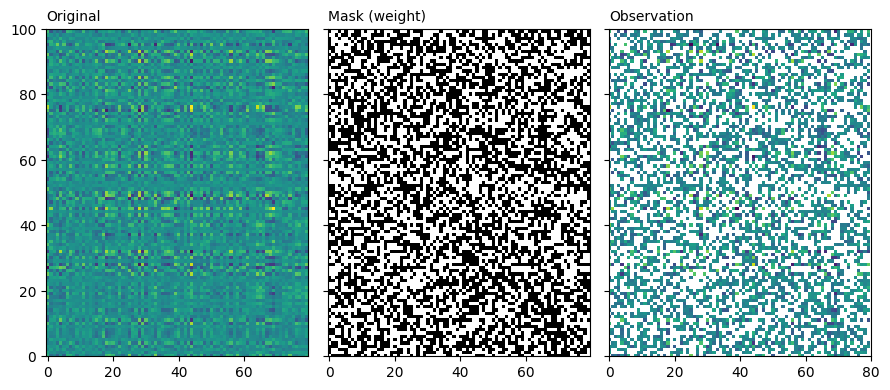

In [3]:
fig, axes = plt.subplots(
    1, 3, figsize=(9, 4), sharey=True)

ax = axes[0]
ax.imshow(data, cmap='viridis')
ax.set_title('Original', fontsize=10, loc='left')

ax = axes[1]
ax.imshow(weight, cmap='gray_r')
ax.set_title('Mask (weight)', fontsize=10, loc='left')

ax = axes[2]
ax.imshow(np.where(weight, data, np.nan), cmap='viridis')
ax.set_title('Observation', fontsize=10, loc='left')

ax.set_xlim(0.0, 80.0)
ax.set_ylim(0.0, 100.0)

fig.tight_layout()
plt.show()

The next cell runs BIRSVD on the observed entries. The missing entries are passed as zeros through `data * weight`, while `weight` tells the solver which values should contribute to the objective.


In [4]:
result = birsvd(data * weight, weight, 5)

The next cell compares the original matrix with the low-rank reconstruction stored in `result.A`. It also plots the residual to show where the approximation differs from the synthetic ground truth.


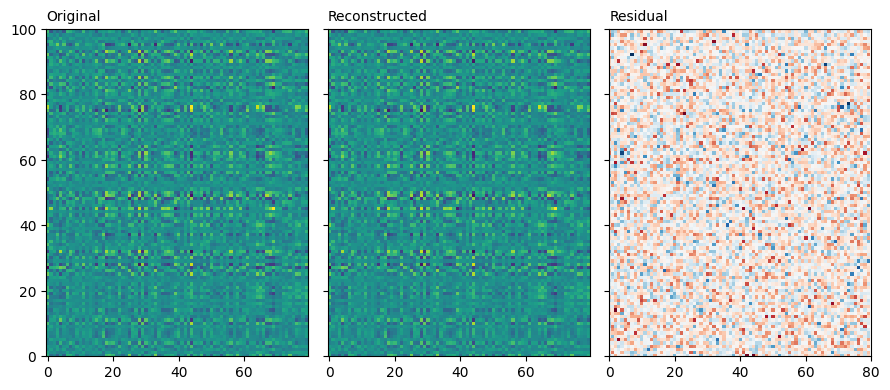

In [5]:
fig, axes = plt.subplots(
    1, 3, figsize=(9, 4), sharey=True)

ax = axes[0]
ax.imshow(data, cmap='viridis')
ax.set_title('Original', fontsize=10, loc='left')

ax = axes[1]
ax.imshow(result.A, cmap='viridis')
ax.set_title('Reconstructed', fontsize=10, loc='left')

ax = axes[2]
ax.imshow(data - result.A, cmap='RdBu')
ax.set_title('Residual', fontsize=10, loc='left')

ax.set_xlim(0.0, 80.0)
ax.set_ylim(0.0, 100.0)

fig.tight_layout()
plt.show()

## Sparse + low-rank decomposition

The next cell builds a second synthetic example with a smooth low-rank background plus sparse positive stochastic signals. This setup is useful for demonstrating iterative separation of background and outlier-like structure.


In [6]:
rng = np.random.default_rng(42)

m, n, r = 100, 80, 5
U = rng.standard_normal((m, r))
V = rng.standard_normal((n, r))
S = rng.exponential(size=r)
background   = (U @ np.diag(S) @ V.T)
signal = np.where(rng.random((m, n)) > 0.9, rng.exponential(100, (m, n)), 0)
data = signal + background

The next cell displays the true low-rank background, the sparse signal component, and their sum. These panels provide the reference components for the iterative decomposition below.


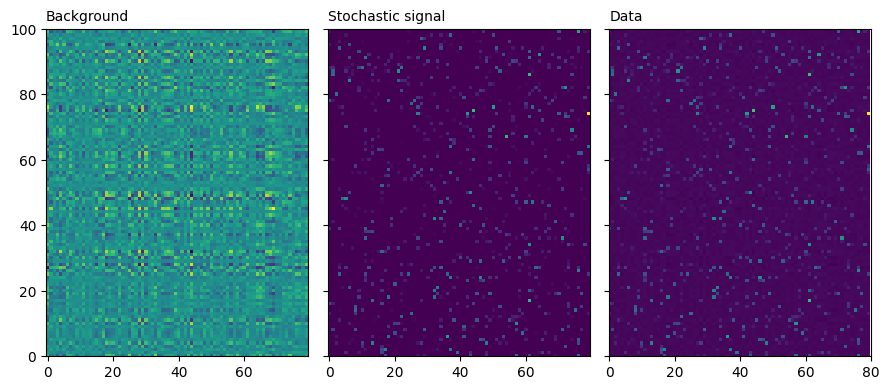

In [7]:
fig, axes = plt.subplots(
    1, 3, figsize=(9, 4), sharey=True)

ax = axes[0]
ax.imshow(background, cmap='viridis')
ax.set_title('Background', fontsize=10, loc='left')

ax = axes[1]
ax.imshow(signal, cmap='viridis')
ax.set_title('Stochastic signal', fontsize=10, loc='left')

ax = axes[2]
ax.imshow(data, cmap='viridis')
ax.set_title('Data', fontsize=10, loc='left')

ax.set_xlim(0.0, 80.0)
ax.set_ylim(0.0, 100.0)

fig.tight_layout()
plt.show()

The next cell alternates between fitting a low-rank component with BIRSVD and updating a non-negative sparse residual. Entries assigned to the sparse component are masked out in the next low-rank fit.


In [8]:
S = np.zeros_like(data)
weight = np.ones_like(data)

for n in range(20):
    result = birsvd(data - S, weight, 8)
    S = np.clip(data - result.A, a_min=0.0, a_max=None)
    weight = np.where(S > 0.0, 0.0, 1.0)

The next cell compares the original background with the low-rank component recovered by the iterative procedure. Similar structure in both panels indicates that the background has been separated successfully.


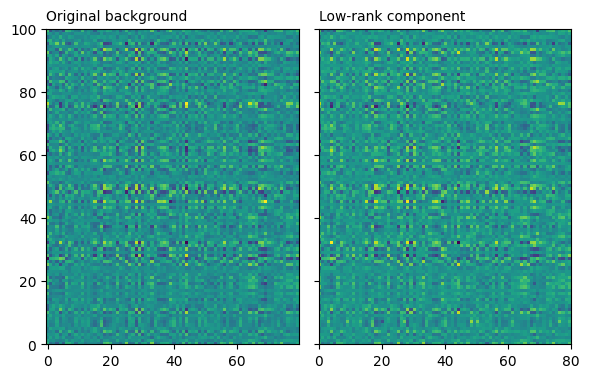

In [9]:
fig, axes = plt.subplots(
    1, 2, figsize=(6, 4), sharey=True)

ax = axes[0]
ax.imshow(background, cmap='viridis')
ax.set_title('Original background', fontsize=10, loc='left')

ax = axes[1]
ax.imshow(result.A, cmap='viridis')
ax.set_title('Low-rank component', fontsize=10, loc='left')

ax.set_xlim(0.0, 80.0)
ax.set_ylim(0.0, 100.0)

fig.tight_layout()
plt.show()

The next cell compares the original sparse signal with the estimated sparse component `S`. This shows how much of the positive stochastic signal was isolated from the low-rank background.


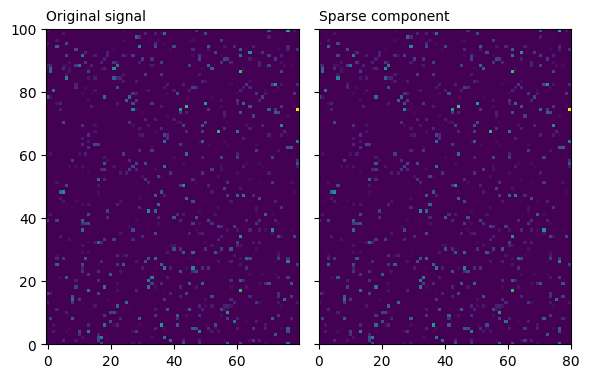

In [10]:
fig, axes = plt.subplots(
    1, 2, figsize=(6, 4), sharey=True)

ax = axes[0]
ax.imshow(signal, cmap='viridis')
ax.set_title('Original signal', fontsize=10, loc='left')

ax = axes[1]
ax.imshow(S, cmap='viridis')
ax.set_title('Sparse component', fontsize=10, loc='left')

ax.set_xlim(0.0, 80.0)
ax.set_ylim(0.0, 100.0)

fig.tight_layout()
plt.show()